In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from matplotlib.patches import Rectangle
from torchvision.ops import box_iou
from ultralytics import YOLO
import ultralytics

**Real YOLO26 inference**

In [2]:
MODEL_ID = "yolo26n.pt"
IMAGE_URL = "https://ultralytics.com/images/bus.jpg"

model = YOLO(MODEL_ID)

result = model.predict(
    source=IMAGE_URL,
    conf=0.25,
    verbose=False
)[0]

print("Original image shape:", result.orig_shape)
print("Number of detections:", len(result.boxes))

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Original image shape: (1080, 810)
Number of detections: 5


**Visualize detections**

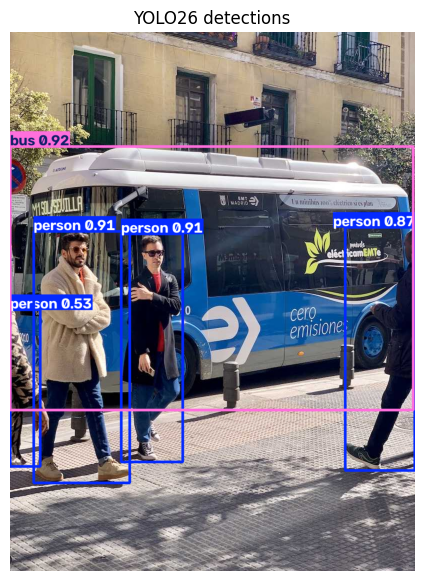

In [3]:
annotated_bgr = result.plot()
annotated_rgb = annotated_bgr[..., ::-1]

plt.figure(figsize=(10, 7))
plt.imshow(annotated_rgb)
plt.title("YOLO26 detections")
plt.axis("off")
plt.show()

**Detection output anatomy**

In [4]:
boxes = result.boxes

print("boxes.xyxy shape :", boxes.xyxy.shape)
print("boxes.xywh shape :", boxes.xywh.shape)
print("boxes.conf shape :", boxes.conf.shape)
print("boxes.cls shape :", boxes.cls.shape)

boxes.xyxy shape : torch.Size([5, 4])
boxes.xywh shape : torch.Size([5, 4])
boxes.conf shape : torch.Size([5])
boxes.cls shape : torch.Size([5])


In [5]:
number_of_show = min(5, len(boxes))

for index in range(number_of_show):
    class_id = int(boxes.cls[index].item())
    class_name = result.names[class_id]
    
    confidence = boxes.conf[index].item()
    xyxy = boxes.xyxy[index].cpu().tolist()
    
    print(f"Detection {index + 1}")
    print("Class      :", class_name)
    print("Confidence :", round(confidence, 4))
    print(
        "XYXY       :",
        [round(value, 2) for value in xyxy]
    )

Detection 1
Class      : bus
Confidence : 0.9236
XYXY       : [0.0, 229.37, 806.1, 757.09]
Detection 2
Class      : person
Confidence : 0.9126
XYXY       : [222.47, 404.94, 345.41, 861.64]
Detection 3
Class      : person
Confidence : 0.9055
XYXY       : [47.69, 399.32, 239.35, 903.02]
Detection 4
Class      : person
Confidence : 0.8701
XYXY       : [670.68, 391.53, 809.81, 878.98]
Detection 5
Class      : person
Confidence : 0.5345
XYXY       : [0.13, 556.69, 60.0, 870.1]


**Inspect all box formats**

In [6]:
if len(boxes) > 0:
    first_index = 0
    
    print("XYXY absolute: ", boxes.xyxy[first_index].cpu().tolist())
    
    print("XYWH absolute: ", boxes.xywh[first_index].cpu().tolist()) # [center_x, center_y, width, height]
    
    print("XYXY normalized: ", boxes.xyxyn[first_index].cpu().tolist())
    
    print("XYWH normalized: ", boxes.xywhn[first_index].cpu().tolist())

XYXY absolute:  [0.0, 229.36883544921875, 806.0955810546875, 757.0858154296875]
XYWH absolute:  [403.04779052734375, 493.2273254394531, 806.0955810546875, 527.7169799804688]
XYXY normalized:  [0.0, 0.21237854659557343, 0.9951797127723694, 0.7010053992271423]
XYWH normalized:  [0.4975898563861847, 0.4566919803619385, 0.9951797127723694, 0.4886268377304077]


**Manual format conversion**

_XYXY → CXCYWH_

In [7]:
def xyxy_to_cxcywh(box):
    x1, y1, x2, y2 = box
    
    width = x2 - x1
    height = y2 - y1
    
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    
    return torch.stack([center_x, center_y, width, height])

In [8]:
first_xyxy = boxes.xyxy[0].detach().cpu()
manual_cxcywh = xyxy_to_cxcywh(first_xyxy)

library_cxcywh = boxes.xywh[0].detach().cpu()

print("Manual conversion :", manual_cxcywh)
print("Library conversion:", library_cxcywh)
torch.testing.assert_close(manual_cxcywh, library_cxcywh)
print("Conversion is correct.")

Manual conversion : tensor([403.0478, 493.2273, 806.0956, 527.7170])
Library conversion: tensor([403.0478, 493.2273, 806.0956, 527.7170])
Conversion is correct.


**Normalize for YOLO format**

In [9]:
image_height, image_width = result.orig_shape

normalization_values = torch.tensor([
    image_width, image_height,
    image_width, image_height
], dtype=torch.float32)

manual_normalized = manual_cxcywh / normalization_values

library_normalized = boxes.xywhn[0].detach().cpu()

print("Manual conversion :", manual_normalized)
print("Library conversion:", library_normalized)

torch.testing.assert_close(
    manual_normalized, library_normalized,
    rtol=1e-4, atol=1e-4
)
print("Normalization is correct.")

Manual conversion : tensor([0.4976, 0.4567, 0.9952, 0.4886])
Library conversion: tensor([0.4976, 0.4567, 0.9952, 0.4886])
Normalization is correct.


**RDD2022 conversion function**

_Pascal VOC → YOLO_

In [10]:
def voc_to_yolo(box_xyxy, image_width, image_height):
    xmin, ymin, xmax, ymax = box_xyxy
    
    box_width = xmax - xmin
    box_height = ymax - ymin
    
    center_x = (xmin + xmax) / 2
    center_y = (ymin + ymax) / 2
    
    return [
        center_x / image_width,
        center_y / image_height,
        box_width / image_width,
        box_height / image_height
    ]

In [11]:
image_width = 640
image_height = 480

voc_box = [64, 48, 320, 240]
yolo_box = voc_to_yolo(voc_box, image_width, image_height)

print("VOC box :", voc_box)
print(
    "YOLO box:",
    [round(value, 4) for value in yolo_box]
)

VOC box : [64, 48, 320, 240]
YOLO box: [0.3, 0.3, 0.4, 0.4]


**Crop using a predicted box**

_Why NumPy uses Y before X_

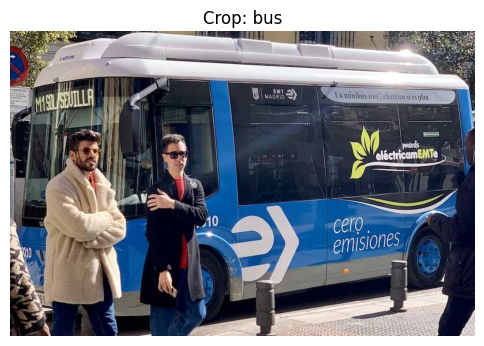

In [12]:
original_rgb = result.orig_img[..., ::-1]

x1, y1, x2, y2 = boxes.xyxy[0].round().int().cpu().tolist()
height, width = original_rgb.shape[:2]

x1 = max(0, min(x1, width - 1))
x2 = max(0, min(x2, width))

y1 = max(0, min(y1, height - 1))
y2 = max(0, min(y2, height))

first_object_crop = original_rgb[
    y1:y2,
    x1:x2
]

plt.figure(figsize=(6, 5))
plt.imshow(first_object_crop)
plt.title(f"Crop: {result.names[int(boxes.cls[0])]}")
plt.axis("off")
plt.show()

## Intersection over Union (IoU)

Measures how much a **predicted box** overlaps a **reference (ground-truth) box**.

$$IoU = \frac{\text{Intersection Area}}{\text{Union Area}}
\qquad\text{where}\qquad
\text{Union} = A + B - \text{Intersection}$$

| IoU | Meaning |
|:---:|---------|
| 0.0 | no overlap |
| 0.5 | typical detection / NMS threshold |
| 1.0 | boxes are identical |

### Worked example (xyxy format)

Box A = [100, 80, 300, 280] → Area A = 200 × 200 = 40,000
Box B = [180, 120, 380, 300] → Area B = 200 × 180 = 36,000


**Step 1 — intersection rectangle** (take the *inner* edges):

left = max(x1_A, x1_B) = max(100, 180) = 180

top = max(y1_A, y1_B) = max( 80, 120) = 120

right = min(x2_A, x2_B) = min(300, 380) = 300

bottom = min(y2_A, y2_B) = min(280, 300) = 280


**Step 2 — areas**

Intersection = (300 - 180) × (280 - 120) = 120 × 160 = 19,200

Union = 40,000 + 36,000 - 19,200 = 56,800

IoU = 19,200 / 56,800 ≈ 0.338


> **Note:** if `right - left ≤ 0` or `bottom - top ≤ 0`, the boxes do not overlap → set Intersection = 0, so IoU = 0. Subtracting the intersection from the union prevents double-counting the shared region.

In [17]:
def calculate_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    
    intersection_x1 = max(ax1, bx1)
    intersection_y1 = max(ay1, by1)
    
    intersection_x2 = min(ax2, bx2)
    intersection_y2 = min(ay2, by2)
    
    intersection_width = max(0, intersection_x2 - intersection_x1)
    intersection_height = max(0, intersection_y2 - intersection_y1)
    
    intersection_area = intersection_width * intersection_height
    
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    
    union_area = area_a + area_b - intersection_area
    if union_area == 0:
        return 0.0
    
    return intersection_area / union_area

In [18]:
box_a = [100, 80, 300, 280]
box_b = [180, 120, 380, 300]

manual_iou = calculate_iou(box_a, box_b)

print("Manual IoU:", round(manual_iou, 4))

Manual IoU: 0.338


In [19]:
box_a_tensor = torch.tensor([box_a], dtype=torch.float32)
box_b_tensor = torch.tensor([box_b], dtype=torch.float32)

torchvision_iou = box_iou(box_a_tensor, box_b_tensor).item()

print("Manual IoU     :", round(manual_iou, 4))
print("TorchVision IoU:", round(torchvision_iou, 4))

Manual IoU     : 0.338
TorchVision IoU: 0.338


**Visualize the overlapping boxes**

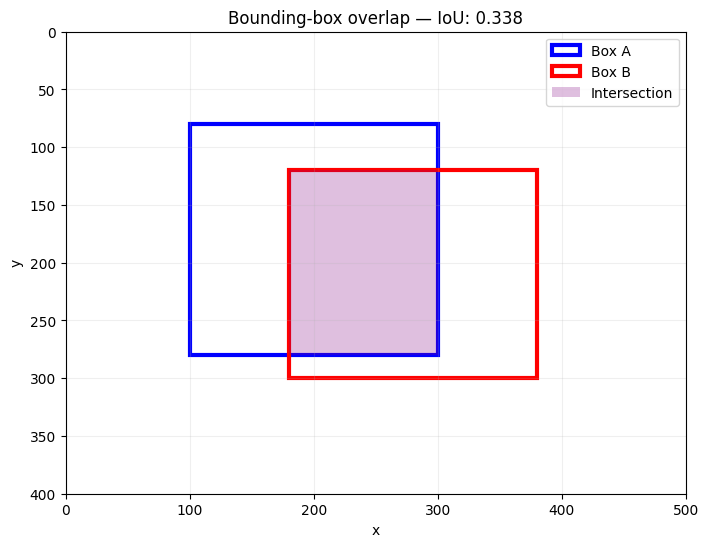

In [22]:
fig, axis = plt.subplots(figsize=(8, 6))

axis.add_patch(Rectangle(
    (100, 80), 200, 200, fill=False, 
    edgecolor="blue", linewidth=3, label="Box A"
))

axis.add_patch(Rectangle(
    (180, 120), 200, 180, fill=False, 
    edgecolor="red", linewidth=3, label="Box B"
))

axis.add_patch(Rectangle(
    (180, 120), 120, 160,
    facecolor="purple", alpha=0.25, label="Intersection"
))

axis.set_xlim(0, 500)
axis.set_ylim(400, 0)

axis.set_xlabel("x")
axis.set_ylabel("y")
axis.set_title(f"Bounding-box overlap — IoU: {manual_iou:.3f}")

axis.legend()
axis.grid(alpha=0.2)

plt.show()

**Important edge cases**

In [23]:
test_cases = {
    "Identical": (
        [0, 0, 100, 100],
        [0, 0, 100, 100],
    ),
    "No overlap" : (
        [0, 0, 100, 100],
        [150, 150, 250, 250]
    ),
    "Touching edge" : (
        [0, 0, 100, 100],
        [100, 0, 200, 100]
    ),
    "Partial overlap" : (
        [0, 0, 100, 100],
        [50, 50, 150, 150]
    )
}

for name, (first_box, second_box) in test_cases.items():
    iou = calculate_iou(first_box, second_box)
    print(f"{name:<16}: {iou:.4f}")

Identical       : 1.0000
No overlap      : 0.0000
Touching edge   : 0.0000
Partial overlap : 0.1429
